# Aggregation — listing-level table (wide)

Grain agreed with the team (Yusuke, 2026-09-08): **one row per Airbnb listing**, with
crime / IPTU / POI attached as columns of the listing's **distrito**.

This build keeps **as many columns as possible** — cleaning/selection comes later.
Spatial unit and join routes were fixed by the feasibility study
(`obsidian-vault/09 - Spatial Aggregation.md`).

**Outputs** (git-ignored):
- `data/processed/listings_aggregated.csv` — 1 row / listing, ~188 cols.
- `data/processed/distrito_features.csv` — 1 row / distrito, ~109 cols.

Column dictionary: `docs/data-dictionary-aggregation.md`.

In [1]:
import warnings, zipfile, unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import requests
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

RAW = Path("../data/raw")
EXT = Path("../data/external")
PROC = Path("../data/processed"); PROC.mkdir(parents=True, exist_ok=True)

def norm(s):
    s = unicodedata.normalize("NFKD", str(s)).encode("ascii", "ignore").decode()
    return " ".join(s.upper().split())

def slug(s):
    s = unicodedata.normalize("NFKD", str(s)).encode("ascii", "ignore").decode().lower()
    return "".join(ch if ch.isalnum() else "_" for ch in s).strip("_").replace("__", "_")

## Distrito boundaries + metadata

In [2]:
dist = gpd.read_file(EXT / "distrito_municipal.geojson")
dist["geometry"] = dist.geometry.make_valid()
dist["distrito"] = dist["nm_distrito_municipal"].map(norm)
dmeta = (dist.set_index("distrito")
             .rename(columns={"nm_regiao_05": "regiao5", "nm_regiao_08": "regiao8",
                              "cd_identificador_subprefeitura": "subprefeitura_cd",
                              "qt_area_quilometro": "area_km2"})
             [["regiao5", "regiao8", "subprefeitura_cd", "area_km2"]])
print(len(dist), "distritos")

96 distritos


## IPTU-SP → distrito (residential, many aggregates)

Route: `numero_contribuinte`[:6] → `quadra_fiscal` → distrito (study: 99.94%).
Values are **fiscal** (venal), well below market — level needs FipeZAP calibration.

In [3]:
q2d = pd.read_csv(EXT / "quadra_to_distrito.csv", dtype={"sq": str}).set_index("sq")["distrito"]
it = pd.read_csv(zipfile.ZipFile(RAW / "IPTU-SP" / "iptu_2025.zip").open("iptu_2025.csv"),
                 low_memory=False, dtype={"numero_contribuinte": str})
it["distrito"] = it["numero_contribuinte"].str.zfill(11).str[:6].map(q2d)

RES = ['Residência', 'Apartamento Em Condomínio',
       'Residência E Outro Uso (Predominância Residencial)',
       'Residência Coletiva, Exclusive Cortiço (Mais De Uma Residência No Lote)',
       'Prédio De Apartamento, Não Em Condomínio, De Uso Exclusivamente Residencial',
       'Flat Residencial Em Condomínio']
r = it[it["finalidade_imovel"].isin(RES) & it["distrito"].notna()].copy()
r["venal_total"]     = r["valor_terreno"] + r["valor_construcao"]
r["venal_m2_constr"] = r["venal_total"]      / r["area_construida"].replace(0, np.nan)
r["terreno_m2"]      = r["valor_terreno"]    / r["area_terreno"].replace(0, np.nan)
r["constr_m2"]       = r["valor_construcao"] / r["area_construida"].replace(0, np.nan)
r["idade"]           = (r["ano"] - r["ano_construcao_corrigida"]).where(lambda s: s.between(0, 150))
r["is_apto"]         = r["finalidade_imovel"].str.contains("Apartamento|Flat", case=False, regex=True)
r = r[(r["venal_m2_constr"] > 50) & (r["venal_m2_constr"] < 200_000)]

iptu = r.groupby("distrito").agg(
    iptu_n=("venal_total", "size"),
    iptu_venal_m2_median=("venal_m2_constr", "median"), iptu_venal_m2_mean=("venal_m2_constr", "mean"),
    iptu_venal_m2_p25=("venal_m2_constr", lambda s: s.quantile(.25)),
    iptu_venal_m2_p75=("venal_m2_constr", lambda s: s.quantile(.75)),
    iptu_terreno_m2_median=("terreno_m2", "median"), iptu_constr_m2_median=("constr_m2", "median"),
    iptu_venal_total_median=("venal_total", "median"),
    iptu_area_constr_median=("area_construida", "median"), iptu_area_terreno_median=("area_terreno", "median"),
    iptu_idade_median=("idade", "median"), iptu_pavimentos_median=("quantidade_pavimento", "median"),
    iptu_share_apto=("is_apto", "mean"))
print("iptu features:", iptu.shape)

iptu features: (96, 13)


## Crime (SSP-SP) → distrito — one column per crime category

Crosswalk from the study (geocoded + 9 hand-mapped). Occurrences only. Per-category
2025 counts, plus `crime_total`, `crime_violento`, `crime_patrimonial`,
`crime_total_2024` (trend), `crime_n_dp`. Distritos with no DP inherit the **nearest**
distrito's row (`crime_source`). Placeholder — needs the team's manual review.

In [4]:
cr = pd.read_csv("../data/processed/ISP/dados_criminais_sao_paulo_2025.csv")
for y in ["2024", "2025"]:
    cr[y] = cr[y].fillna(0)
cr["bairro"] = cr["DP"].str.split(" - ").str[-1].str.strip()
occ = cr[~cr["NATUREZA2"].str.startswith("Nº DE VÍTIMAS")].copy()

xw = pd.read_csv(EXT / "dp_to_distrito.csv")
MANUAL = {"Jardim Mirna": "CAMPO GRANDE", "Parque Santo Antônio": "JARDIM SAO LUIS",
          "Parque São Rafael": "SAO RAFAEL", "Vale do Aricanduva": "ARICANDUVA",
          "Vila Alpina": "SAPOPEMBA", "Vila Diva": "ARICANDUVA",
          "Vila Pereira Barreto": "VILA GUILHERME", "Vila Rica": "JARAGUA",
          "Vila Santa Maria": "TREMEMBE"}
xw["distrito"] = xw.apply(lambda x: MANUAL.get(x["bairro"], x["distrito"]), axis=1)
xw["review_status"] = np.where(xw["bairro"].isin(MANUAL), "manual-guess", "geocoded")
xw = xw.dropna(subset=["distrito"])
xw[["bairro", "distrito", "review_status"]].to_csv(EXT / "dp_distrito_crosswalk.csv", index=False)

m2 = occ.merge(xw[["bairro", "distrito"]], on="bairro", how="inner")
piv = m2.pivot_table(index="distrito", columns="NATUREZA2", values="2025", aggfunc="sum", fill_value=0)
piv.columns = ["crime_" + slug(x) for x in piv.columns]
piv["crime_total"] = piv.sum(axis=1)
piv["crime_patrimonial"] = piv[[x for x in piv.columns if "furto" in x or "roubo" in x]].sum(axis=1)
VIOL = ["homicidio", "latrocinio", "seguida_de_morte", "tentativa_de_homicidio", "estupro"]
piv["crime_violento"] = (piv[[x for x in piv.columns
                              if any(v in x for v in VIOL) or "roubo" in x]].sum(axis=1))
piv["crime_total_2024"] = (m2.pivot_table(index="distrito", columns="NATUREZA2", values="2024",
                                          aggfunc="sum", fill_value=0).sum(axis=1))
ndp = xw.groupby("distrito")["bairro"].nunique().rename("crime_n_dp")
crime_direct = piv.div(piv.join(ndp)["crime_n_dp"], axis=0).join(ndp)   # per-DP mean

dd = dist.to_crs(31983).set_index("distrito")
dd["cx"] = dd.geometry.centroid
have, miss = dd[dd.index.isin(crime_direct.index)], dd[~dd.index.isin(crime_direct.index)]
nearest = {d: have.assign(x=have["cx"].distance(row["cx"])).nsmallest(1, "x").index[0]
           for d, row in miss.iterrows()}
crime = pd.concat([crime_direct, crime_direct.loc[list(nearest.values())].set_axis(list(nearest))])
crime["crime_source"] = ["dp-direct"] * len(crime_direct) + ["nearest-imputed"] * len(nearest)
print("crime features:", crime.shape, "|", len(crime_direct), "direct +", len(nearest), "imputed")

crime features: (96, 22) | 71 direct + 25 imputed


## POI → distrito by category (OSM Overpass, placeholder for Google Places)

Counts and per-km² densities for each `tourism` / `historic` / `leisure` / food-and-drink
`amenity` category, plus `poi_total`.

In [5]:
POI_FILE = EXT / "poi_by_distrito_cat.csv"
if not POI_FILE.exists():
    minx, miny, maxx, maxy = dist.total_bounds
    q = f'''[out:json][timeout:240];
    (
     node["tourism"]({miny},{minx},{maxy},{maxx});
     node["historic"]({miny},{minx},{maxy},{maxx});
     node["leisure"~"park|garden|nature_reserve|stadium"]({miny},{minx},{maxy},{maxx});
     node["amenity"~"restaurant|bar|cafe|nightclub|theatre|cinema|marketplace"]({miny},{minx},{maxy},{maxx});
    );
    out center;'''
    import time
    eps = ["https://overpass-api.de/api/interpreter",
           "https://overpass.kumi.systems/api/interpreter",
           "https://overpass.private.coffee/api/interpreter"]
    data = None
    for k in range(8):
        rr = requests.post(eps[k % len(eps)], data={"data": q}, timeout=260,
                           headers={"User-Agent": "ssc0957/1.0"})
        if rr.status_code == 200 and rr.text.strip().startswith("{"):
            data = rr.json(); break
        time.sleep(25)
    rows = []
    for e in data["elements"]:
        t = e.get("tags", {})
        lat = e.get("lat") or e.get("center", {}).get("lat")
        lon = e.get("lon") or e.get("center", {}).get("lon")
        if lat is None:
            continue
        cat = ("tourism_" + t["tourism"] if "tourism" in t else
               "historic" if "historic" in t else
               "leisure_" + t["leisure"] if "leisure" in t else
               "amenity_" + t.get("amenity", ""))
        rows.append((lat, lon, cat))
    pdf = pd.DataFrame(rows, columns=["lat", "lon", "cat"])
    gp = gpd.GeoDataFrame(pdf, geometry=gpd.points_from_xy(pdf.lon, pdf.lat), crs="EPSG:4326")
    j = gpd.sjoin(gp, dist[["distrito", "geometry"]], how="inner", predicate="within")
    pv = j.pivot_table(index="distrito", columns="cat", aggfunc="size", fill_value=0)
    pv.columns = ["poi_" + x for x in pv.columns]
    pv["poi_total"] = pv.sum(axis=1)
    pv = pv.join(dist.set_index("distrito")["qt_area_metro"])
    for col in [x for x in pv.columns if x.startswith("poi_")]:
        pv[col.replace("poi_", "poidens_")] = pv[col] / (pv["qt_area_metro"] / 1e6)
    pv.drop(columns=["qt_area_metro"]).to_csv(POI_FILE)

poi = pd.read_csv(POI_FILE).set_index("distrito")
print("poi features:", poi.shape)

poi features: (90, 70)


## Distrito feature table

In [6]:
feat = dmeta.join(iptu).join(crime).join(poi, how="left")
poi_cols = [c for c in poi.columns]
feat[poi_cols] = feat[poi_cols].fillna(0)
feat.to_csv(PROC / "distrito_features.csv")
print("distrito_features:", feat.shape, "| columns with nulls:",
      feat.columns[feat.isna().any()].tolist())
feat.head()

distrito_features: (96, 109) | columns with nulls: []


,regiao5,regiao8,subprefeitura_cd,area_km2,iptu_n,iptu_venal_m2_median,iptu_venal_m2_mean,iptu_venal_m2_p25,iptu_venal_m2_p75,iptu_terreno_m2_median,...,poidens_tourism_hotel,poidens_tourism_information,poidens_tourism_motel,poidens_tourism_museum,poidens_tourism_picnic_site,poidens_tourism_theme_park,poidens_tourism_viewpoint,poidens_tourism_wilderness_hut,poidens_tourism_yes,poidens_total
distrito,,,,,,,,,,,,,,,,,,,,,
RIO PEQUENO,Oeste,Oeste,21,9.657,3465,60.242857,71.794880,56.491803,74.438596,0.643778,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.517759
CIDADE TIRADENTES,Leste,Leste 2,30,14.939,9674,67.875000,65.402020,53.846154,70.826087,2.284615,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.066939,0.0,0.0,0.736325
JARDIM SAO LUIS,Sul,Sul 2,24,26.048,3884,53.645833,66.150825,50.600000,78.733333,0.429333,...,0.076783,0.115174,0.0,0.0,0.0,0.0,0.038391,0.0,0.0,0.767827
PONTE RASA,Leste,Leste 2,8,6.597,1997,59.700000,64.777079,54.540000,70.200000,4.366071,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.303183
LIBERDADE,Centro,Centro,14,3.651,26609,91.319588,111.127643,69.951923,126.320755,3.827769,...,0.821664,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,44.369830


## Listing-level table

All non-empty `listings.csv` columns + `price_num` + every distrito feature, joined on
`distrito` (`neighbourhood_cleansed`, 100% == point-in-polygon per the study).

In [7]:
EMPTY = ['neighborhood_overview', 'host_since', 'host_response_time', 'host_response_rate',
         'host_acceptance_rate', 'host_thumbnail_url', 'host_neighbourhood',
         'host_total_listings_count', 'host_verifications', 'neighbourhood',
         'calendar_updated', 'license', 'instant_bookable']
li = pd.read_csv(RAW / "Airbnb" / "listings.csv", low_memory=False).drop(columns=EMPTY)
li["price_num"] = li["price"].replace(r"[\$,]", "", regex=True).astype(float)
li["distrito"] = li["neighbourhood_cleansed"].map(norm)

lm = li.merge(feat.reset_index(), on="distrito", how="left")
lm.to_csv(PROC / "listings_aggregated.csv", index=False)
print(f"listings_aggregated: {lm.shape[0]:,} rows x {lm.shape[1]} cols "
      f"({li.shape[1]} listing + {feat.shape[1]} distrito)")
print(f"distrito features attached: {lm['crime_total'].notna().mean()*100:.1f}%")
lm.groupby("crime_source").size()

listings_aggregated: 42,354 rows x 188 cols (79 listing + 109 distrito)
distrito features attached: 100.0%


crime_source
dp-direct          28279
nearest-imputed    14075
dtype: int64

In [8]:
# sanity: distrito columns are constant within a distrito
g = lm[lm["distrito"] == "PINHEIROS"]
print("PINHEIROS:", len(g), "listings |",
      "crime_total unique:", g["crime_total"].nunique(),
      "| iptu_venal_m2_median unique:", g["iptu_venal_m2_median"].nunique())
lm.head(3)

PINHEIROS: 2838 listings | crime_total unique: 1 | iptu_venal_m2_median unique: 1


,id,listing_url,scrape_id,last_scraped,source,name,description,picture_url,host_id,host_url,...,poidens_tourism_hotel,poidens_tourism_information,poidens_tourism_motel,poidens_tourism_museum,poidens_tourism_picnic_site,poidens_tourism_theme_park,poidens_tourism_viewpoint,poidens_tourism_wilderness_hut,poidens_tourism_yes,poidens_total
0,4917,https://www.airbnb.com/rooms/4917,20260614072545,2026-06-16,city scrape,Resort Condo Near Av. Paulista,"Comfortable 2 bedrooms (1 master suite), 2 bat...",https://a0.muscache.com/pictures/hosting/Hosti...,5618,https://www.airbnb.com/users/show/5618,...,0.930472,0.000000,0.0,0.116309,0.0,0.0,0.116309,0.0,0.0,19.190979
1,54614,https://www.airbnb.com/rooms/54614,20260614072545,2026-06-16,city scrape,Nice area/Cozy flat/ Building rooftop pool,"Small, modern and charming flat. Cozy standard...",https://a0.muscache.com/pictures/31da1f7a-2d33...,256576,https://www.airbnb.com/users/show/256576,...,1.063963,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,17.023413
2,82935,https://www.airbnb.com/rooms/82935,20260614072545,2026-06-14,city scrape,Oscar Freire - Hospital das Clínicas e Nu Bank,I live in a 3-bedroom apartment in the most re...,https://a0.muscache.com/pictures/1cb69bb6-bb68...,451565,https://www.airbnb.com/users/show/451565,...,1.939672,0.323279,0.0,0.484918,0.0,0.0,0.000000,0.0,0.0,45.259025


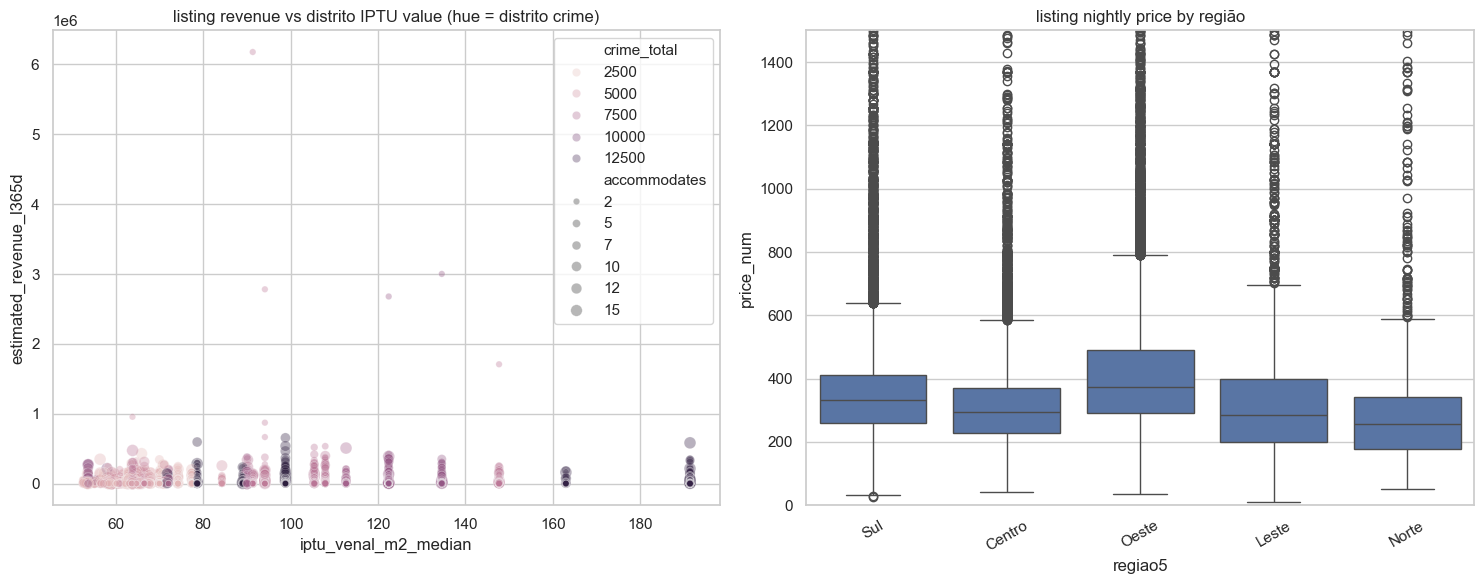

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
d = lm[lm["estimated_revenue_l365d"] > 0]
sns.scatterplot(data=d, x="iptu_venal_m2_median", y="estimated_revenue_l365d",
                hue="crime_total", size="accommodates", alpha=0.35, ax=ax[0], legend="brief")
ax[0].set_title("listing revenue vs distrito IPTU value (hue = distrito crime)")
sns.boxplot(data=lm, x="regiao5", y="price_num", ax=ax[1])
ax[1].set_ylim(0, 1500); ax[1].tick_params(axis="x", rotation=30)
ax[1].set_title("listing nightly price by região")
plt.tight_layout(); plt.show()

## Output summary

| File | Grain | Shape | Use |
|---|---|---|---|
| `data/processed/listings_aggregated.csv` | 1 listing | ~42k × ~188 | modeling table |
| `data/processed/distrito_features.csv` | 1 distrito | 96 × ~109 | EDA, maps, Phase 2 |

Column families: listing attributes (Airbnb, ~79) · distrito meta (`regiao5/8`,
`subprefeitura_cd`, `area_km2`) · IPTU (`iptu_*`, 13) · crime (`crime_*` per category +
totals + trend, ~22) · POI (`poi_*` / `poidens_*` per category + total, ~71).

**Deliberately wide — cleaning/selection is the next step.** Known gaps
(`09 - Spatial Aggregation.md`): crime crosswalk review + real imputation; population
for crime rates; Google Places instead of OSM; FipeZAP deflation of IPTU; property-profile
clustering.